## MLP con múltiples salidas

Iris es el género de una planta herbácea con flores que se utilizan en decoración. Dentro de este género existen muy diversas especies, entre las que se han estudiado: Iris setosa, Iris versicolor e Iris virginica.
Estas tres especies pueden distinguirse según las dimensiones de sus pétalos y sépalos. Un grupo de investigadores ha recopilado la información correspondiente a las longitudes y anchos de los pétalos y sépalos de 50 plantas de cada especie. 
En el archivo iris81 trn.csv se encuentra el conjunto de entrenamiento, y en iris81 tst.csv el de prueba, generado a partir de estas mediciones (en cm), junto con un código binario que indica la clase de cada muestra (especie) reconocida por el grupo de investigadores:
([−1, −1, 1] = setosa,
[−1, 1, −1] = versicolor,
[1, −1, −1] = virginica)


### Inicialización


In [1]:
import numpy as np
import pandas as pd
import random as random
import copy


class Capa:
    w : np.ndarray
    y: np.ndarray
    delta: np.ndarray

    def __init__(self, w_i, y_i, delta_i):
        self.w = w_i
        self.y = y_i
        self.delta = delta_i

    def mostrar(self):
        print(f"Pesos: {self.w}")
        print(f"Salidas: {self.y}")
        print(f"Deltas: {self.delta}\n")


def sigm(x):
    return (2/(1+np.exp(-x))) - 1

entrada_usuario = [4,4,3] 

tabla = pd.read_csv('../../Data/gtp_2/iris81_trn.csv', header=None).to_numpy()
x0 = -np.ones(len(tabla))
entradas = np.c_[x0, tabla[:,:4]] # extraer las primeras 4 columnas
yd_vect =  tabla[:, 4:] # extraer desde la quinta hasta el final

print(entradas.shape)
print(yd_vect.shape)

w = np.random.rand(entrada_usuario[0], len(entradas[0])) - 0.5
y_init = np.zeros(entrada_usuario[0])
delta = np.zeros(entrada_usuario[0])
cap = Capa(w,y_init,delta)
vect_capas = [copy.deepcopy(cap)]

# Iniciar red (aleatorio):
for i in range(1,len(entrada_usuario)):
    w = np.random.rand(entrada_usuario[i], entrada_usuario[i-1]+1) - 0.5
    y_init = np.zeros(entrada_usuario[i])
    delta = np.zeros(entrada_usuario[i])
    cap = Capa(w,y_init,delta)
    vect_capas.append(copy.deepcopy(cap))


# Visualizar red inicial:
print(f"Cantidad de capas: {len(vect_capas)}\n")
print(f"Red neuronal: \n")
i = 1
for capa in vect_capas:
    print(f"Capa: {i}")
    capa.mostrar()
    i += 1


(111, 5)
(111, 3)
Cantidad de capas: 3

Red neuronal: 

Capa: 1
Pesos: [[ 0.26467365 -0.14599873  0.16856217 -0.03004389 -0.00096081]
 [-0.47052563  0.32032943  0.25536157 -0.11895727  0.14425853]
 [-0.27724592  0.46036953 -0.44831865  0.2316558  -0.36917171]
 [-0.26092332  0.14665507  0.30749708  0.43902121 -0.001699  ]]
Salidas: [0. 0. 0. 0.]
Deltas: [0. 0. 0. 0.]

Capa: 2
Pesos: [[ 0.12756117 -0.01816527 -0.01753971 -0.37806683  0.40523595]
 [ 0.41840533 -0.09911324 -0.42698129 -0.04488196 -0.02751538]
 [-0.00912318 -0.49503625 -0.32333471  0.45750899  0.37917277]
 [ 0.37842046  0.15363831 -0.36882621  0.47844413 -0.49693356]]
Salidas: [0. 0. 0. 0.]
Deltas: [0. 0. 0. 0.]

Capa: 3
Pesos: [[-0.45563436 -0.01257645  0.17738211 -0.12229596 -0.31895596]
 [ 0.00321661 -0.44746266  0.36008389 -0.28054931 -0.1051884 ]
 [-0.16466604 -0.1392888   0.39574068  0.16606498 -0.44601745]]
Salidas: [0. 0. 0.]
Deltas: [0. 0. 0.]



### Entrenamiento


In [2]:
# Iterar sobre la red:

epoca = 1
epoca_max = 500
mu = 0.05

# n -> ejemplo actual
# i -> la capa
# j -> la neurona
while epoca < epoca_max: 

    for n in range(len(entradas)):

        # paso hacia adelante
        for i in range(len(vect_capas)):
            for j in range(len(vect_capas[i].y)):
                if i==0:
                    z = np.dot(entradas[n,:],vect_capas[i].w[j,:])
                else: 
                    ent = np.r_[-1,vect_capas[i-1].y]
                    z = np.dot(ent,vect_capas[i].w[j,:])
                vect_capas[i].y[j] = sigm(z)

        # propagacion hacia atras
        for i in range(len(vect_capas)-1,-1,-1):
            for j in range(len(vect_capas[i].y)):
                
                if i==len(vect_capas)-1: 
                    vect_capas[i].delta[j] = (1/2) * (yd_vect[n,j] - vect_capas[i].y[j]) * (1 + vect_capas[i].y[j]) * (1 - vect_capas[i].y[j])
                else:
                    vect_capas[i].delta[j] = (1/2) * np.dot(vect_capas[i+1].delta, vect_capas[i+1].w[:,j+1])  * (1 + vect_capas[i].y[j]) * (1 - vect_capas[i].y[j])

        #actualizar los pesos
        for i in range(len(vect_capas)):
            for j in range(len(vect_capas[i].y)):
                for m in range(len(vect_capas[i].w[j])):
                    if i==0:
                        vect_capas[i].w[j,m] += mu*vect_capas[i].delta[j]*entradas[n,m]
                    else:
                        
                        ent = np.r_[-1, vect_capas[i-1].y]
                        vect_capas[i].w[j,m] += mu*vect_capas[i].delta[j]*ent[m]
                        
    # Verificación:
    acierto = 0
    for n in range(len(entradas)):
        for capa in range(len(vect_capas)):
            for neuron in range(len(vect_capas[capa].y)):
                if capa==0:
                    z = np.dot(entradas[n,:],vect_capas[capa].w[neuron,:])
                else:                
                    ent = np.r_[-1,vect_capas[capa-1].y]
                    z = np.dot(ent,vect_capas[capa].w[neuron,:])

                vect_capas[capa].y[neuron] = sigm(z)

        salida_red = vect_capas[-1].y # la salida es un vector de 3

        idx_max = np.argmax(salida_red)
        for idx in range(len(salida_red)):
            if idx == idx_max:
                salida_red[idx] = 1
            else:
                salida_red[idx] = -1

        if ((salida_red == yd_vect[n,:]).all()): # si salida_red coincide exactamente con el deseado para el ejemplo 'n' --> acierto
            acierto += 1

    tasa_acierto = acierto/len(entradas)
    print(f"Fin entrenamiento. Epoca: {epoca}, Tasa de acierto: {tasa_acierto * 100: .2f}\n")

    if tasa_acierto >= 0.99:
        print(f"Convergencia. Tasa de aciertos: {tasa_acierto}, Epoca: {epoca}\n")
        break
    else:
        epoca += 1

print(f"Red neuronal final: \n")
i = 1
for cap in vect_capas:
    print(f"Capa {i}:")
    cap.mostrar()
    i += 1



Fin entrenamiento. Epoca: 1, Tasa de acierto:  40.54

Fin entrenamiento. Epoca: 2, Tasa de acierto:  40.54

Fin entrenamiento. Epoca: 3, Tasa de acierto:  55.86

Fin entrenamiento. Epoca: 4, Tasa de acierto:  71.17

Fin entrenamiento. Epoca: 5, Tasa de acierto:  71.17

Fin entrenamiento. Epoca: 6, Tasa de acierto:  71.17

Fin entrenamiento. Epoca: 7, Tasa de acierto:  85.59

Fin entrenamiento. Epoca: 8, Tasa de acierto:  99.10

Convergencia. Tasa de aciertos: 0.990990990990991, Epoca: 8

Red neuronal final: 

Capa 1:
Pesos: [[ 0.44917016 -0.56826457 -0.58099176  1.03926875  0.49130452]
 [-0.46206747  0.26969082  0.24399041 -0.17012964  0.1286252 ]
 [-0.10378462  0.01481255 -1.19458387  1.18252563  0.0617958 ]
 [-0.30649702  0.36289902  0.46831512  0.46088018 -0.0066789 ]]
Salidas: [-0.92550296  0.83634189 -0.69667133  0.9776509 ]
Deltas: [-0.00222357  0.00087067 -0.00944567  0.00029604]

Capa 2:
Pesos: [[ 0.05035911 -0.59016467  0.07947096 -0.93309976  0.45901345]
 [ 0.61509746 -0.1294

### Test: iris_tst


In [3]:
tabla_tst = pd.read_csv('../../Data/gtp_2/iris81_tst.csv', header=None).to_numpy()

x0_tst = -np.ones(len(tabla_tst))
entradas_tst = np.c_[x0_tst, tabla_tst[:,:4]] 
yd_tst =  tabla_tst[:, 4:]

acierto = 0
for n in range(len(entradas_tst)):
    for capa in range(len(vect_capas)):
        for neuron in range(len(vect_capas[capa].y)):
            if capa==0:
                z = np.dot(entradas_tst[n,:],vect_capas[capa].w[neuron,:])
            else:                
                ent = np.r_[-1,vect_capas[capa-1].y]
                z = np.dot(ent,vect_capas[capa].w[neuron,:])

            vect_capas[capa].y[neuron] = sigm(z)

    salida_red_tst = vect_capas[-1].y # la salida es un vector de 3
    idx_max = np.argmax(salida_red_tst)
    for idx in range(len(salida_red_tst)):
        if idx == idx_max:
            salida_red_tst[idx] = 1
        else:
            salida_red_tst[idx] = -1

    if ((salida_red_tst == yd_tst[n,:]).all()): # si salida_red coincide exactamente con el deseado para el ejemplo 'n' --> acierto
        acierto += 1

tasa_acierto = acierto/len(entradas_tst)
print(f"Test: Tasa de acierto: {tasa_acierto * 100: .2f}%")


Test: Tasa de acierto:  91.89%


### Parte 2

Explore cómo varı́a el desempeño al usar distintas tasas de aprendizaje, y para cada caso grafique las curvas de error cuadrático total y error de clasificación en función de las épocas de entrenamiento.

In [4]:
# Iterar sobre la red:

epoca = 1
epoca_max = 500
mu = [0.2, 0.01, 0.5, 0.45, 0.25] 
k = 0 # variable para pasar de mu

# diccionarios para los errores de todas las epocas de cada tasa de aprendizaje
error_cuad_h = {}
error_clas_h = {}

# n -> ejemplo actual
# i -> la capa
# j -> la neurona
while k < len(mu):
    # volver a inicializar la red
    epoca = 1
    np.random.seed(40)

    # errores para cada epoca
    error_cuad_e = []
    error_clas_e = []

    w = np.random.rand(entrada_usuario[0], len(entradas[0])) - 0.5
    y_init = np.zeros(entrada_usuario[0])
    delta = np.zeros(entrada_usuario[0])
    cap = Capa(w,y_init,delta)
    vect_capas = [copy.deepcopy(cap)]

    # Iniciar red
    for i in range(1,len(entrada_usuario)):
        w = np.random.rand(entrada_usuario[i], entrada_usuario[i-1]+1) - 0.5
        y_init = np.zeros(entrada_usuario[i])
        delta = np.zeros(entrada_usuario[i])
        cap = Capa(w,y_init,delta)
        vect_capas.append(copy.deepcopy(cap))

    # volver a iterar
    while epoca < epoca_max: 

        for n in range(len(entradas)):

            # paso hacia adelante
            for i in range(len(vect_capas)):
                for j in range(len(vect_capas[i].y)):
                    if i==0:
                        z = np.dot(entradas[n,:],vect_capas[i].w[j,:])
                    else: 
                        ent = np.r_[-1,vect_capas[i-1].y]
                        z = np.dot(ent,vect_capas[i].w[j,:])
                    vect_capas[i].y[j] = sigm(z)

            # propagacion hacia atras
            for i in range(len(vect_capas)-1,-1,-1):
                for j in range(len(vect_capas[i].y)):
                    
                    if i==len(vect_capas)-1: 
                        vect_capas[i].delta[j] = (1/2) * (yd_vect[n,j] - vect_capas[i].y[j]) * (1 + vect_capas[i].y[j]) * (1 - vect_capas[i].y[j])
                    else:
                        vect_capas[i].delta[j] = (1/2) * np.dot(vect_capas[i+1].delta, vect_capas[i+1].w[:,j+1])  * (1 + vect_capas[i].y[j]) * (1 - vect_capas[i].y[j])

            #actualizar los pesos
            for i in range(len(vect_capas)):
                for j in range(len(vect_capas[i].y)):
                    for m in range(len(vect_capas[i].w[j])):
                        if i==0:
                            vect_capas[i].w[j,m] += mu[k]*vect_capas[i].delta[j]*entradas[n,m]
                        else:
                            
                            ent = np.r_[-1, vect_capas[i-1].y]
                            vect_capas[i].w[j,m] += mu[k]*vect_capas[i].delta[j]*ent[m]
                            
        # Verificación:
        acierto = 0
        error_cuad = 0
        for n in range(len(entradas)):
            for capa in range(len(vect_capas)):
                for neuron in range(len(vect_capas[capa].y)):
                    if capa==0:
                        z = np.dot(entradas[n,:],vect_capas[capa].w[neuron,:])
                    else:                
                        ent = np.r_[-1,vect_capas[capa-1].y]
                        z = np.dot(ent,vect_capas[capa].w[neuron,:])

                    vect_capas[capa].y[neuron] = sigm(z)

            salida_red = vect_capas[-1].y # la salida es un vector de 3

            error_cuad += np.sum((yd_vect[n,:] - salida_red)**2) # '**' equivale a potencia
            
            idx_max = np.argmax(salida_red)
            for idx in range(len(salida_red)):
                if idx == idx_max:
                    salida_red[idx] = 1
                else:
                    salida_red[idx] = -1

            if ((salida_red == yd_vect[n,:]).all()): # si salida_red coincide exactamente con el deseado para el ejemplo 'n' --> acierto
                acierto += 1

        tasa_acierto = acierto/len(entradas)
        error_clasificacion = 1 - tasa_acierto # el error es el complemento del acierto

        error_cuad_e.append(error_cuad)
        error_clas_e.append(error_clasificacion)

        if tasa_acierto >= 0.99:
            print(f"Convergencia. Tasa de aciertos: {tasa_acierto}, Epoca: {epoca}, Tasa aprendizaje: mu = {mu[k]}\n")
            break
        else:
            epoca += 1

        
    if epoca == epoca_max:
        print(f"No hubo convergencia ({epoca_max} epocas) - {tasa_acierto * 100: .2f}%. Tasa aprendizaje: mu = {mu[k]}\n")

    # guardar para la tasa 'k' los errores que obtuvo
    error_cuad_h[mu[k]] = error_cuad_e
    error_clas_h[mu[k]] = error_clas_e

    k += 1
    if k >= len(mu):
        break



No hubo convergencia (500 epocas) -  69.37%. Tasa aprendizaje: mu = 0.2

Convergencia. Tasa de aciertos: 0.990990990990991, Epoca: 68, Tasa aprendizaje: mu = 0.01

No hubo convergencia (500 epocas) -  28.83%. Tasa aprendizaje: mu = 0.5

No hubo convergencia (500 epocas) -  28.83%. Tasa aprendizaje: mu = 0.45

No hubo convergencia (500 epocas) -  69.37%. Tasa aprendizaje: mu = 0.25



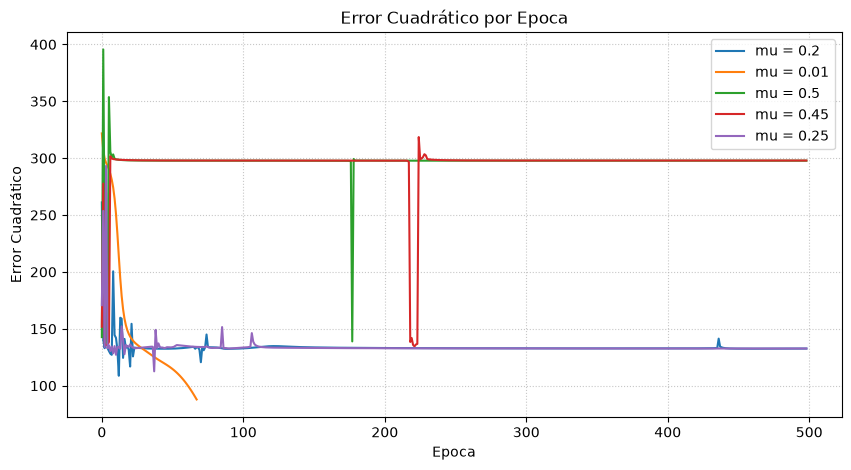

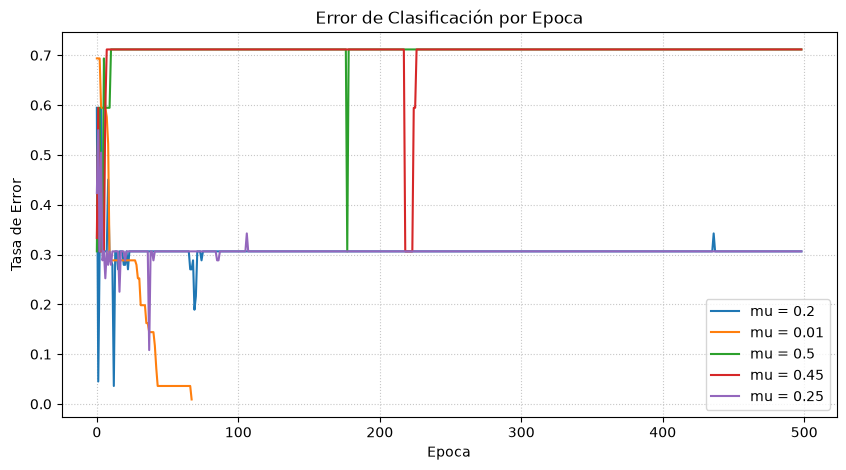

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

# graficar
plt.figure(1,figsize=(10, 5))
for tasa, errores in error_cuad_h.items():
    plt.plot(errores, label=f'mu = {tasa}')

plt.title('Error Cuadrático por Epoca')
plt.xlabel('Epoca')
plt.ylabel('Error Cuadrático')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

plt.figure(2,figsize=(10, 5))
for tasa, errores in error_clas_h.items():
    plt.plot(errores, label=f'mu = {tasa}')

plt.title('Error de Clasificación por Epoca')
plt.xlabel('Epoca')
plt.ylabel('Tasa de Error')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()
